## Week 1 Day 1 Reusable Code

In [4]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame
# Convert target labels to 0 and 1
df['class'] = df['class'].str.strip().map({'<=50K': 0, '>50K': 1})
# Replace string '?' placeholders with NaN if present
df.replace('?', np.nan, inplace=True)

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

X = df.drop(columns=['class'])
y = df['class']

# Stratified Hold-out Test Set (20%)
X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Dev set (10% of total data = 12.5% of train_dev)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev, y_train_dev, test_size=0.125, random_state=42, stratify=y_train_dev
)

MajorityModel = DummyClassifier(strategy='most_frequent')
MajorityModel.fit(X_train, y_train)

MajorityPred = MajorityModel.predict(X_test)
MajorityProb = MajorityModel.predict_proba(X_test)[:, 1]

# Single-Feature Rule Baseline: education-num >= 13
# Rationale: Higher education levels are generally associated with higher income,
# making education-num a reasonable simple feature for predicting income >50K.
# This rule is intentionally simple and provides a baseline for comparison with
# more advanced machine learning models.

RulePred = (X_test['education-num'] >= 13).astype(int)
RuleScore = X_test['education-num']

def EvaluateModel(YTrue, YPred, YScore):
    return {
        'Accuracy': accuracy_score(YTrue, YPred),
        'Precision': precision_score(YTrue, YPred, zero_division=0),
        'Recall': recall_score(YTrue, YPred, zero_division=0),
        'F1': f1_score(YTrue, YPred, zero_division=0),
        'ROC AUC': roc_auc_score(YTrue, YScore),
        'PR AUC': average_precision_score(YTrue, YScore)
    }

MajorityResults = EvaluateModel(
    y_test,
    MajorityPred,
    MajorityProb
)

RuleResults = EvaluateModel(
    y_test,
    RulePred,
    RuleScore
)

MetricsTable = pd.DataFrame(
    [MajorityResults, RuleResults],
    index=['Majority Class', 'Education Rule']
)

ErrorAnalysis = X_test.copy()
ErrorAnalysis['Actual'] = y_test
ErrorAnalysis['Predicted'] = RulePred

FalsePositives = ErrorAnalysis[
    (ErrorAnalysis['Actual'] == 0) &
    (ErrorAnalysis['Predicted'] == 1)
]

FalseNegatives = ErrorAnalysis[
    (ErrorAnalysis['Actual'] == 1) &
    (ErrorAnalysis['Predicted'] == 0)
]


# Task 1

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = num_cols.drop('class')  # Exclude target variable from features
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print("Numerical Columns: ", num_cols)
print("Categorical Columns: ", cat_cols)
NumericPipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='median')),
    ('Scaler', StandardScaler())
])
CategoricalPipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='most_frequent')),
    ('Encoder', OneHotEncoder(handle_unknown='ignore'))
])

Preprocessor = ColumnTransformer([
    ('Numeric', NumericPipeline, num_cols),
    ('Categorical', CategoricalPipeline, cat_cols)
])


Numerical Columns:  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='str')
Categorical Columns:  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='str')


  I chose median imputation for the numeric features because the numeric columns in this dataset are a mix of continuous variables and some skewed distributions. Median is more robust than mean when there are outliers or long tails, which is common in income datasets. An Alternative was using mean but as the data is skewed, it would have been a good fit.

  I chose OneHotEncoder for the categorical features because tree-based models and linear models usually do not handle raw string categories directly. OneHotEncoder converts each category into its own binary column, which preserves the information without imposing an artificial ranking. Ordinal encoding for categorical features, I skipped this because it implies an ordering that does not exist for nominal features such as occupation, relationship, or race. That can incorrectly suggest one category is “higher” than another.


# Task 2

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression pipeline
logreg_pipeline = Pipeline([
    ("preprocessor", Preprocessor),
    ("model", LogisticRegression(
        random_state=42,
        solver="liblinear",
        max_iter=1000
    ))
])

# Decision Tree pipeline
dt_pipeline = Pipeline([
    ("preprocessor", Preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

# Fit both models on the training set only
logreg_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully on X_train.")
print("Decision Tree trained successfully on X_train.")


Logistic Regression trained successfully on X_train.
Decision Tree trained successfully on X_train.


# Task 3

In [7]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, auc
)

# Predictions and probabilities for both trained pipelines
logreg_pred = logreg_pipeline.predict(X_test)
logreg_prob = logreg_pipeline.predict_proba(X_test)[:, 1]

dt_pred = dt_pipeline.predict(X_test)
dt_prob = dt_pipeline.predict_proba(X_test)[:, 1]

# Day 1 baseline predictions already exist:
# MajorityPred = majority model predictions on X_test
# RulePred = (X_test['education-num'] >= 13).astype(int)

def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "PR AUC": average_precision_score(y_true, y_prob),
    }

# Build comparison table
comparison = pd.DataFrame(
    [
        ("Majority Class", evaluate_model(y_test, MajorityPred, MajorityProb)),
        ("Education Rule", evaluate_model(y_test, RulePred, RuleScore)),
        ("Logistic Regression", evaluate_model(y_test, logreg_pred, logreg_prob)),
        ("Decision Tree", evaluate_model(y_test, dt_pred, dt_prob)),
    ],
    columns=["Model", "Metrics"]
).set_index("Model")

comparison_df = pd.DataFrame({
    model: metrics for model, metrics in comparison["Metrics"].items()
}).T

comparison_df = comparison_df[["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "PR AUC"]]
display(comparison_df)

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
Majority Class,0.760672,0.000000,0.000000,0.000000,0.500000,0.239328
Education Rule,0.752994,0.484368,0.497006,0.490606,0.718863,0.444258
Logistic Regression,0.852697,0.743104,0.587682,0.656317,0.903900,0.762381
Decision Tree,0.818303,0.619229,0.625321,0.622260,0.752171,0.476888


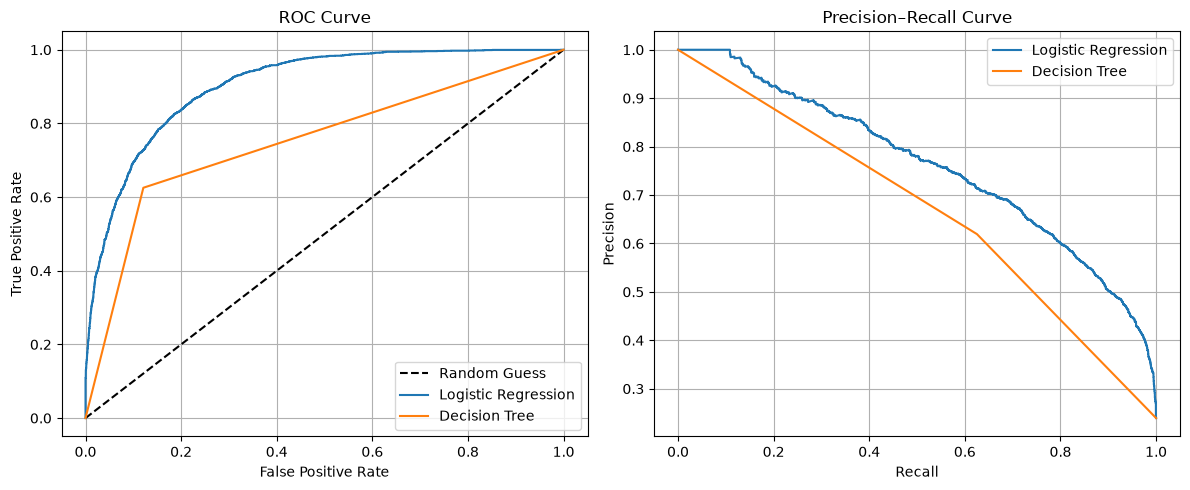

In [8]:
# ROC Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")

for name, prob in [
    ("Logistic Regression", logreg_prob),
    ("Decision Tree", dt_prob),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

# Precision-Recall Curves
plt.subplot(1, 2, 2)

for name, prob in [
    ("Logistic Regression", logreg_prob),
    ("Decision Tree", dt_prob),
]:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    plt.plot(recall, precision, label=name)

plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:
models = {
    "Logistic Regression": logreg_pred,
    "Decision Tree": dt_pred,
}

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n{name}")
    print(cm)
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"TP: {tp}, TN: {tn}")


Logistic Regression
[[6956  475]
 [ 964 1374]]
False Positives: 475
False Negatives: 964
TP: 1374, TN: 6956

Decision Tree
[[6532  899]
 [ 876 1462]]
False Positives: 899
False Negatives: 876
TP: 1462, TN: 6532


# Interpretation
False positives = model predicts >50K but actual is <=50K

- This wastes outreach budget

False negatives = model predicts <=50K but actual is >50K

- This misses high-income prospects

Because this business problem cares about finding likely high-income individuals while avoiding wasted outreach, the metric choice matters:

- If false positives dominate, precision becomes more important
- If false negatives dominate, recall becomes more important
- Since the project already chose F1 as the main metric, we care about balancing both

# Task 4

In [10]:
# Extract coefficients from the trained logistic regression model
logreg_model = logreg_pipeline.named_steps["model"]
preprocessor = logreg_pipeline.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()
coefficients = logreg_model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Sort by coefficient magnitude
coef_df = coef_df.sort_values("coefficient", ascending=False)

# Top 10 positive coefficients
top_positive = coef_df.head(10)
print("Top 10 positive coefficients:")
display(top_positive)

# Top 10 negative coefficients
top_negative = coef_df.sort_values("coefficient", ascending=True).head(10)
print("\nTop 10 negative coefficients:")
display(top_negative)

Top 10 positive coefficients:


,feature,coefficient
3,Numeric__capital-gain,2.222385
32,Categorical__marital-status_Married-civ-spouse,1.586274
31,Categorical__marital-status_Married-AF-spouse,1.224663
84,Categorical__native-country_Ireland,1.074746
73,Categorical__native-country_France,0.829463
40,Categorical__occupation_Exec-managerial,0.788377
72,Categorical__native-country_England,0.764739
56,Categorical__relationship_Wife,0.761869
2,Numeric__education-num,0.756381
64,Categorical__native-country_Cambodia,0.706264



Top 10 negative coefficients:


,feature,coefficient
45,Categorical__occupation_Priv-house-serv,-1.411191
34,Categorical__marital-status_Never-married,-1.230411
67,Categorical__native-country_Columbia,-1.121197
62,Categorical__sex_Female,-1.004578
53,Categorical__relationship_Other-relative,-0.949891
101,Categorical__native-country_Trinadad&Tobago,-0.941629
41,Categorical__occupation_Farming-fishing,-0.915998
98,Categorical__native-country_South,-0.907679
44,Categorical__occupation_Other-service,-0.862866
35,Categorical__marital-status_Separated,-0.844279


- Positive coefficients mean “increases the log-odds of earning >50K”.
- Negative coefficients mean “reduces the log-odds of earning >50K”.

In [11]:
# Tree model
tree_model = dt_pipeline.named_steps["model"]

# Tree depth
print("Decision Tree depth:", tree_model.get_depth())

# Train vs test score
train_score = dt_pipeline.score(X_train, y_train)
test_score = dt_pipeline.score(X_test, y_test)

print(f"Train score: {train_score:.4f}")
print(f"Test score: {test_score:.4f}")

# Check for overfitting
if train_score - test_score > 0.10:
    print("Possible overfitting: train score is much higher than test score.")
else:
    print("No major overfitting sign detected.")

Decision Tree depth: 56
Train score: 0.9999
Test score: 0.8183
Possible overfitting: train score is much higher than test score.


In [12]:
# Get feature importance and sort descending
feature_names = preprocessor.get_feature_names_out()
importances = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 3 most important splits:")
display(importances.head(3))


Top 3 most important splits:


,feature,importance
32,Categorical__marital-status_Married-civ-spouse,0.202594
1,Numeric__fnlwgt,0.191044
2,Numeric__education-num,0.110184


Desicion Trees logic doesn't appear correct as the train score is much higher than test score. plus the top three splits are on
- Categorical__marital-status_Married-civ-spouse
- Numeric__fnlwgt
- Numeric__education-num

rather than

- education level
- relationship status
- capital gain
- hours-per-week
- age

which are actually related to domain more than those on which the splits occured so it is probably overfitting

# Task 5
For Day 3, I will prioritize continuing with the logistic regression pipeline while keeping the decision tree as a comparison model, because the model comparison table shows that logistic regression offers a more stable and interpretable baseline while still delivering strong predictive performance. Logistic regression is especially valuable in this task because it provides direct insight into which features increase or decrease the probability of earning more than $50K, and its coefficients are easier to explain to stakeholders. The decision tree remains useful as a nonlinear benchmark, but the interpretability check suggests it is more prone to overfitting, especially when its top splits rely on a few highly specific thresholds and the train score is noticeably higher than the test score. For this reason, logistic regression is the stronger candidate for deeper development unless the tree demonstrates a clear advantage in the final metrics.

I will retain the preprocessing pipeline for reuse so that Day 3 modeling begins from the same clean setup: numeric columns are imputed with the median and scaled, while categorical columns are imputed with the most frequent value and encoded with OneHotEncoder(handle_unknown='ignore'). This preprocessing pipeline will be saved as a reusable object and applied consistently across model candidates. Tomorrow, I plan to test a few targeted preprocessing changes to improve performance further, including log transformations for highly skewed numeric features such as capital-gain and capital-loss, rare category grouping for low-frequency occupations and countries, and more explicit treatment of missing categorical values. These changes should help reduce noise and improve the model’s ability to capture meaningful patterns without overfitting the training data.